Import and settings


In [2]:
import os
import joblib
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from narwhals.stable.v1.selectors import categorical
from pandas.io.parsers.base_parser import validate_parse_dates_presence

from sklearn.base import BaseEstimator, TransformerMixin, OneToOneFeatureMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
from lightgbm import LGBMClassifier

# Настройки отображения
pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

print("✅ Библиотеки успешно импортированы.")

✅ Библиотеки успешно импортированы.


In [3]:
data_path = "data/application_train.csv"
df = pd.read_csv(data_path)

EDA


In [4]:
display(df.head())

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3
0,100001,0,Cash loans,F,N,N,0,184000.0,151500.0,6090.0,143400.0,Unaccompanied,Pensioner,Secondary / secondary special,Married,House / apartment,-19753,-7711,-1794,-2527,0.8355,0.0371,0.0184
1,100002,1,Cash loans,M,N,Y,0,38000.0,175000.0,7000.0,159300.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,-15120,-8164,-761,-3866,0.1077,0.6090,0.7770
2,100003,0,Revolving loans,M,Y,Y,0,67000.0,993500.0,58510.0,914800.0,Unaccompanied,Working,Secondary / secondary special,Married,House / apartment,-24215,-3277,-4080,-4101,0.2464,0.2629,0.1149
3,100004,0,Cash loans,F,N,N,0,248000.0,753500.0,31020.0,721500.0,Unaccompanied,Pensioner,Higher education,Married,House / apartment,-17584,-5451,-281,-2345,0.3118,0.4461,0.9458
4,100005,0,Cash loans,F,N,Y,0,138000.0,1195000.0,94380.0,1172800.0,Unaccompanied,Commercial associate,Lower secondary,Married,House / apartment,-20044,-5200,-4071,-940,0.2947,0.3732,0.7366


In [5]:
df.shape

(2000, 23)

In [6]:
df.size

46000

In [7]:
df.isnull().sum()

SK_ID_CURR             0
TARGET                 0
NAME_CONTRACT_TYPE     0
CODE_GENDER            0
FLAG_OWN_CAR           0
FLAG_OWN_REALTY        0
CNT_CHILDREN           0
AMT_INCOME_TOTAL       0
AMT_CREDIT             0
AMT_ANNUITY            0
AMT_GOODS_PRICE        0
NAME_TYPE_SUITE        0
NAME_INCOME_TYPE       0
NAME_EDUCATION_TYPE    0
NAME_FAMILY_STATUS     0
NAME_HOUSING_TYPE      0
DAYS_BIRTH             0
DAYS_EMPLOYED          0
DAYS_REGISTRATION      0
DAYS_ID_PUBLISH        0
EXT_SOURCE_1           0
EXT_SOURCE_2           0
EXT_SOURCE_3           0
dtype: int64

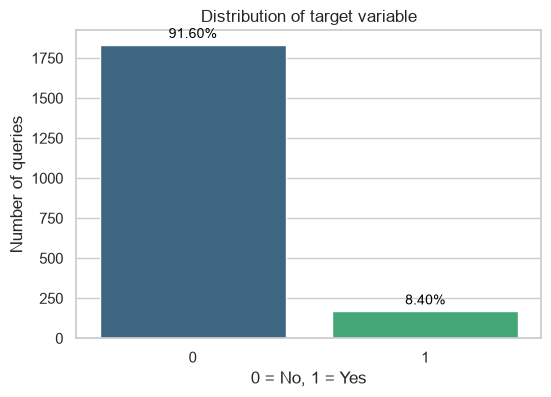

In [11]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='TARGET', data=df, palette='viridis')
plt.title('Distribution of target variable')
plt.xlabel('0 = No, 1 = Yes')
plt.ylabel('Number of queries')

total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')
plt.show()

In [17]:
missing = df.isnull().sum()
display(missing.tolist())

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Feature engineering


In [22]:
class FinancialRatiosTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        # Financial Ratios (Финансовые коэффициенты)
        X['CREDIT_INCOME_PERCENT'] = X['AMT_CREDIT'] / (X['AMT_INCOME_TOTAL'] + 1e-6)
        X['ANNUITY_INCOME_PERCENT'] = X['AMT_ANNUITY'] / (X['AMT_INCOME_TOTAL'] + 1e-6)
        X['CREDIT_TERM'] = X['AMT_CREDIT'] / (X['AMT_ANNUITY'] + 1e-6)
        X['GOODS_PRICE_RATIO'] = X['AMT_CREDIT'] / (X['AMT_GOODS_PRICE'] + 1e-6)

        if 'DAYS_BIRTH' in X.columns:
            X['AGE_YEARS'] = -X['DAYS_BIRTH'] / 365.0

        return X

Preprocessing Pipeline


In [26]:
X = df.drop(columns = ["SK_ID_CURR", 'TARGET'])
y = df["TARGET"]

num_cols = X.select_dtypes(include = ["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include = ["object", "category"]).columns.tolist()

new_num_cols = ["CREDIT_INCOME_PERCENT", "ANNUITY_INCOME_PERCENT", "CREDIT_TERM", "GOODS_PRICE_RATIO", "AGE_YEARS"]
num_cols.extend([col for col in new_num_cols if col not in num_cols])

numeric_transformer = Pipeline(steps = [
	("imputer", SimpleImputer(strategy="median")),
	("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps = [
	("imputer", SimpleImputer(strategy="most_frequent")),
	("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(transformers=[
	("num", numeric_transformer, num_cols),
	("cat", categorical_transformer, cat_cols)
])

Cross-validation and training the model LightGBM

In [27]:
scale_pos_weight = (len(y)-sum(y))/sum(y)


pipeline = Pipeline(steps = [
	('ratios', FinancialRatiosTransformer()),
	('preprocessor', preprocessor),
	('classifier', LGBMClassifier(
		n_estimators=300,
		learning_rate = 0.03,
		num_leaves=30,
		scale_pos_weight=scale_pos_weight,
		random_state = 42,
		n_jobs=-1,
		verbose=1
    ))
])

skf = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
oof_predictions = np.zeros(len(df))


for fold, (train_index, val_index) in enumerate(skf.split(df, y)):
	X_train, y_train = X.iloc[train_index], y.loc[train_index]
	X_val, y_val = X.iloc[val_index], y.loc[val_index]
	pipeline.fit(X_train, y_train)
	val_predictions = pipeline.predict_proba(X_val)[:,1]
	oof_predictions[val_index] = val_predictions

	fold_auc = roc_auc_score(y_val, val_predictions)
	fold_gini = 2 * fold_auc - 1
	print(f"Fold {fold + 1} | ROC-AUC: {fold_auc:.4f} | Gini: {fold_gini:.4f}")

total_auc = roc_auc_score(y, oof_predictions)
total_gini = 2 * total_auc - 1
print(f"Overall OOF ROC-AUC: {total_auc:.4f}")
print(f"Overall OOF Gini:    {total_gini:.4f}")


[LightGBM] [Info] Number of positive: 135, number of negative: 1465
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001166 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4143
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.084375 -> initscore=-2.384336
[LightGBM] [Info] Start training from score -2.384336
Fold 1 | ROC-AUC: 0.4782 | Gini: -0.0437
[LightGBM] [Info] Number of positive: 135, number of negative: 1465
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000563 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4143
[LightGBM] [Info] Number of data points in the train set: 1600, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0

Evaluation of the model | Visualisation of ROC


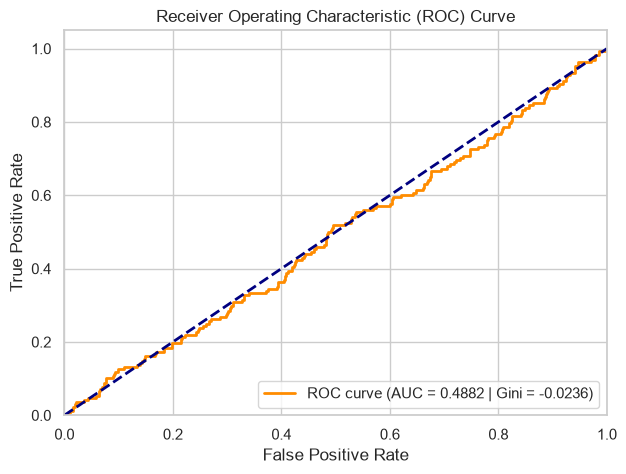

In [28]:
# Построение ROC-кривой
fpr, tpr, _ = roc_curve(y, oof_predictions)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {total_auc:.4f} | Gini = {total_gini:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

Training the final model


In [32]:
pipeline.fit(X, y)

os.makedirs("models", exist_ok=True)
model_path = "models/home_credit_pipeline.pkl"

joblib.dump(pipeline, model_path)
print(f"Pipeline saved in `{model_path}`")

[LightGBM] [Info] Number of positive: 168, number of negative: 1832
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001330 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4143
[LightGBM] [Info] Number of data points in the train set: 2000, number of used features: 46
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.084000 -> initscore=-2.389200
[LightGBM] [Info] Start training from score -2.389200
Pipeline saved in `models/home_credit_pipeline.pkl`


In [51]:
loaded_pipeline = joblib.load(model_path)

sample_data = X.iloc[[112]]
predicted_prob = loaded_pipeline.predict_proba(sample_data)[:, 1][0]

print(f"Predicted prob: {predicted_prob:.4f}")
print("Status:", "rejected" if predicted_prob > 0.5 else "approved")

Predicted prob: 0.9607
Status: rejected
